## Startup Procedure

### Imports

In [51]:
import pycocotools
import vision_utils
import os
import json
import torch
import numpy as np
from PIL import Image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### Setup Dataset

In [52]:
class BroccoliGraspingDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transforms=None):
        self.root = root
        self.split_path = os.path.join(root, split)
        self.transforms = transforms
        # Filters for .png files and ensures they are sorted
        self.file_names = sorted([f[:-4] for f in os.listdir(self.split_path) if f.endswith('.png')])

    def __getitem__(self, idx):
        file_id = self.file_names[idx]
        img_path = os.path.join(self.split_path, f"{file_id}.png")
        json_path = os.path.join(self.split_path, f"{file_id}.json")

        img = Image.open(img_path).convert("RGB")
        with open(json_path) as f:
            data = json.load(f)

        boxes = []
        keypoints = []
        
        for shape in data['shapes']:
            # LabelMe circles are defined by a centre point and a point on the edge
            if shape['shape_type'] == 'circle':
                points = shape['points']
                cx, cy = points[0] # Centre (x, y)
                ex, ey = points[1] # Edge (x, y)
                
                # Euclidean distance for radius: sqrt((x2-x1)^2 + (y2-y1)^2)
                radius = np.sqrt((ex - cx)**2 + (ey - cy)**2)
                
                # Build XYXY bounding box: [xmin, ymin, xmax, ymax]
                boxes.append([cx - radius, cy - radius, cx + radius, cy + radius])
                
                # Keypoint format: [x, y, visibility=2]
                keypoints.append([cx, cy, 2])

        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((len(boxes),), dtype=torch.int64) # Class 1 = Broccoli
        
        # Reshape keypoints to [N, 1, 3] (N objects, 1 point per object, 3 values)
        keypoints_tensor = torch.as_tensor(keypoints, dtype=torch.float32).reshape(-1, 1, 3)

        # Wrap image and boxes in tv_tensors (supported in v0.15+)
        img = tv_tensors.Image(img)
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img)),
            "labels": labels,
            "keypoints": keypoints_tensor, # PLAIN TENSOR: Avoids 'AttributeError'
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.file_names)

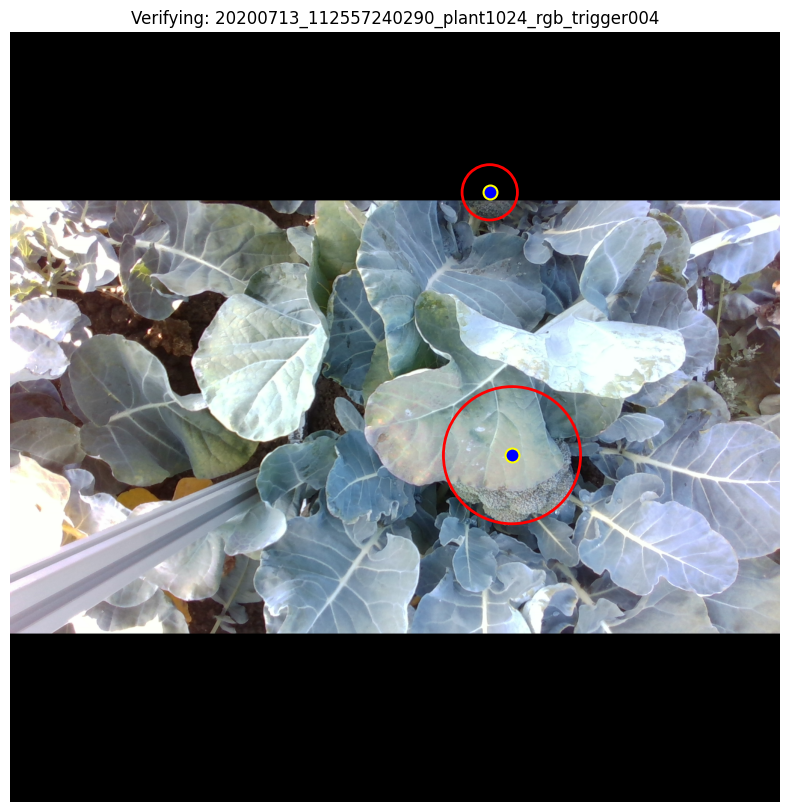

In [63]:
base_path = r"Data\broccoli"
check_dataset = BroccoliGraspingDataset(base_path, split="train", transforms=None)
example = 42

img, target = check_dataset[example]

# 3. Convert (C, H, W) tensor to (H, W, C) for Matplotlib
plot_img = img.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(plot_img)

# 4. Iterate through found broccoli heads
for i in range(len(target['boxes'])):
    # Get center from keypoint tensor [N, 1, 3]
    cx, cy = target['keypoints'][i, 0, 0], target['keypoints'][i, 0, 1]
    
    # Get radius back from our box calculation
    box = target['boxes'][i]
    radius = (box[2] - box[0]) / 2
    
    # Draw Red Circle 
    circle = patches.Circle((cx, cy), radius, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(circle)
    
    # Draw Grasping Point Dot
    ax.scatter(cx, cy, s=100, c='blue', edgecolors='yellow', linewidth=1.5, label='Grasping Point')

plt.title(f"Verifying: {check_dataset.file_names[example]}")
plt.axis('off')
plt.show()